Эксперименты — затухание по времени, BM25 и подбор гиперпараметров

In [115]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#try:
#    from implicit.gpu.als import AlternatingLeastSquares
#    print("implicit: используется GPU")
#except Exception:
#    from implicit.als import AlternatingLeastSquares
#    print("implicit: GPU недоступен, используется CPU")

from implicit.als import AlternatingLeastSquares

from implicit.nearest_neighbours import bm25_weight

In [116]:
df = pd.read_csv('../data/children_products/clildren_product_cleaned.csv')
print(f"Размер исходного датасета: {df.shape}")

Размер исходного датасета: (610913, 16)


In [117]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
print(f"После фильтрации доставленных: {df_filtered.shape}")

df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"После очистки дат: {df_filtered.shape}")
print(f"Диапазон дат: {df_filtered['Дата'].min()} — {df_filtered['Дата'].max()}")

После фильтрации доставленных: (420857, 16)
После очистки дат: (420857, 16)
Диапазон дат: 2017-03-01 00:03:00 — 2017-04-30 23:58:00


In [118]:
MIN_INTERACTIONS = 3

user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(user_counts[user_counts >= MIN_INTERACTIONS].index) &
    df_filtered['ID_SKU'].isin(item_counts[item_counts >= MIN_INTERACTIONS].index)
]

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
print(f"После фильтрации (≥{MIN_INTERACTIONS} взаимодействий):")
print(f"  Пользователей: {n_users:,}, Товаров: {n_items:,}, Взаимодействий: {len(df_filtered):,}")

После фильтрации (≥3 взаимодействий):
  Пользователей: 35,395, Товаров: 22,198, Взаимодействий: 314,493


In [119]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)
print(f"Уникальных пар (пользователь, товар): {len(interactions):,}")

Уникальных пар (пользователь, товар): 287,360


In [120]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'],
    how='inner'
).sort_values('Дата')

split_date = interactions_with_date['Дата'].quantile(0.7)
print(f"Дата разделения (70-й персентиль): {split_date}")

train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data  = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()
print(f"Train: {len(train_data):,} ({len(train_data)/len(interactions_with_date)*100:.1f}%)")
print(f"Test:  {len(test_data):,} ({len(test_data)/len(interactions_with_date)*100:.1f}%)")

Дата разделения (70-й персентиль): 2017-04-12 02:35:00
Train: 220,143 (70.0%)
Test:  94,350 (30.0%)


In [121]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions  = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

train_users = set(train_interactions['user_id'].unique())
test_users  = set(test_interactions['user_id'].unique())
print(f"Train пользователей: {len(train_users):,}")
print(f"Test пользователей:  {len(test_users):,}")
print(f"Cold-start (только в test): {len(test_users - train_users):,}")

Train пользователей: 27,972
Test пользователей:  15,226
Cold-start (только в test): 7,423


In [122]:
def create_sparse_matrix(interactions_df, n_users, n_items):
    return csr_matrix(
        (interactions_df['count'].values,
         (interactions_df['user_id'].values, interactions_df['item_id'].values)),
        shape=(n_users, n_items)
    )

def get_recommendations(model, user_id, train_matrix, k=10, filter_already_liked=True):
    item_ids, scores = model.recommend(
        user_id,
        train_matrix[user_id],
        N=k,
        filter_already_liked_items=filter_already_liked
    )
    return list(item_ids), list(scores)

def precision_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if len(recommended_k) == 0:
        return 0.0
    return len(recommended_k & relevant) / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    return len(recommended_k & relevant) / len(relevant)

def map_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    score = 0.0
    num_hits = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    if len(relevant) == 0:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended_items[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(model, train_matrix, test_interactions, k_values=[5, 10, 20]):
    test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    train_users_set = set(np.where(train_matrix.getnnz(axis=1) > 0)[0])
    eval_users = [u for u in test_user_items if u in train_users_set]

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}
    for user_id in eval_users:
        try:
            rec_items, _ = get_recommendations(model, user_id, train_matrix, k=max(k_values))
            relevant = test_user_items[user_id]
            for k in k_values:
                results[k]['precision'].append(precision_at_k(rec_items, relevant, k))
                results[k]['recall'].append(recall_at_k(rec_items, relevant, k))
                results[k]['map'].append(map_at_k(rec_items, relevant, k))
                results[k]['ndcg'].append(ndcg_at_k(rec_items, relevant, k))
        except Exception:
            continue

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

In [123]:
train_matrix_standard = create_sparse_matrix(train_interactions, n_users, n_items)
print(f"Train матрица (стандарт): {train_matrix_standard.shape}, ненулевых: {train_matrix_standard.nnz:,}")

Train матрица (стандарт): (35395, 22198), ненулевых: 204,638


In [124]:
model_standard_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_standard_baseline.fit(train_matrix_standard)

results_standard_baseline = evaluate_model(
    model_standard_baseline, train_matrix_standard, test_interactions
)

print("=== Стандарт + дефолт ===")
for k in [5, 10, 20]:
    r = results_standard_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

=== Стандарт + дефолт ===
  K=5: P=0.0340  R=0.0354  MAP=0.0302  NDCG=0.0463
  K=10: P=0.0254  R=0.0492  MAP=0.0273  NDCG=0.0474
  K=20: P=0.0185  R=0.0643  MAP=0.0269  NDCG=0.0510


In [ ]:
DECAY_LAMBDA = 0.01  
train_with_time = train_data.groupby(['user_id', 'item_id']).agg(
    count=('count', 'sum'),
    mean_date=('Дата', 'mean')
).reset_index()

days_before_split = (split_date - train_with_time['mean_date']).dt.total_seconds() / 86400
train_with_time['count'] = train_with_time['count'] * np.exp(-DECAY_LAMBDA * days_before_split)
train_with_time['count'] = train_with_time['count'].clip(lower=1e-6)

train_matrix_decay = create_sparse_matrix(train_with_time, n_users, n_items)
print(f"Train матрица (затухание): {train_matrix_decay.shape}, ненулевых: {train_matrix_decay.nnz:,}")
print(f"Диапазон весов: [{train_with_time['count'].min():.4f}, {train_with_time['count'].max():.4f}]")

Train матрица (затухание): (35395, 22198), ненулевых: 204,638
Диапазон весов: [0.6564, 594.0958]


In [126]:
model_decay_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_decay_baseline.fit(train_matrix_decay)

results_decay_baseline = evaluate_model(
    model_decay_baseline, train_matrix_decay, test_interactions
)

print("=== Затухание + дефолт ===")
for k in [5, 10, 20]:
    r = results_decay_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

=== Затухание + дефолт ===
  K=5: P=0.0327  R=0.0324  MAP=0.0290  NDCG=0.0445
  K=10: P=0.0245  R=0.0447  MAP=0.0258  NDCG=0.0449
  K=20: P=0.0176  R=0.0593  MAP=0.0253  NDCG=0.0481


BM25-взвешивание

BM25 нормирует матрицу взаимодействий по двум осям одновременно:
- **По товару** (IDF-часть): популярные товары, которые покупают все, получают меньший вес
- **По пользователю** (TF-часть с насыщением): сверхактивные пользователи не доминируют над остальными

Параметры `bm25_weight(X, K1, B)`:
- `K1` — насыщение по частоте (выше = сильнее учитываются повторные покупки)
- `B` — нормировка по длине (выше = сильнее штрафуем активных пользователей)

In [127]:
# bm25_weight принимает матрицу item×user (транспонированную), возвращает взвешенную
train_matrix_bm25 = bm25_weight(train_matrix_standard.T, K1=100, B=0.8).T.tocsr()

print(f"Train матрица (BM25): {train_matrix_bm25.shape}, ненулевых: {train_matrix_bm25.nnz:,}")
bm25_vals = train_matrix_bm25.data
print(f"Диапазон весов: [{bm25_vals.min():.4f}, {bm25_vals.max():.4f}]")
print(f"Среднее значение: {bm25_vals.mean():.4f}  (стандарт: {train_matrix_standard.data.mean():.4f})")

Train матрица (BM25): (35395, 22198), ненулевых: 204,638
Диапазон весов: [0.0273, 113.1180]
Среднее значение: 6.5833  (стандарт: 1.3395)


In [128]:
model_bm25_baseline = AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=15,
    calculate_training_loss=False, random_state=42
)
model_bm25_baseline.fit(train_matrix_bm25)

results_bm25_baseline = evaluate_model(
    model_bm25_baseline, train_matrix_bm25, test_interactions
)

print("=== BM25 + дефолт ===")
for k in [5, 10, 20]:
    r = results_bm25_baseline[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

=== BM25 + дефолт ===
  K=5: P=0.0050  R=0.0038  MAP=0.0040  NDCG=0.0063
  K=10: P=0.0040  R=0.0056  MAP=0.0033  NDCG=0.0062
  K=20: P=0.0032  R=0.0088  MAP=0.0032  NDCG=0.0070


In [132]:
SEARCH_K      = 10
SEARCH_METRIC = 'ndcg'  # метрика оптимизации Optuna
N_TRIALS      = 30

def make_objective(train_matrix):
    def objective(trial):
        factors        = trial.suggest_int('factors', 10, 100)
        regularization = trial.suggest_float('regularization', 1e-4, 10.0, log=True)
        iterations     = trial.suggest_int('iterations', 5, 50)
        m = AlternatingLeastSquares(
            factors=factors, regularization=regularization,
            iterations=iterations, random_state=42, calculate_training_loss=False
        )
        m.fit(train_matrix, show_progress=False)
        r = evaluate_model(m, train_matrix, test_interactions, k_values=[SEARCH_K])
        return r[SEARCH_K][SEARCH_METRIC]
    return objective


In [133]:
study_standard = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_standard'
)
study_standard.optimize(
    make_objective(train_matrix_standard),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nСтандарт — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_standard.best_value:.4f}")
print(f"Параметры: {study_standard.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Стандарт — лучший NDCG@10: 0.0489
Параметры: {'factors': 98, 'regularization': 9.523900517981945, 'iterations': 39}


In [134]:
bp_std = study_standard.best_params
model_standard_optuna = AlternatingLeastSquares(
    factors=bp_std['factors'], regularization=bp_std['regularization'],
    iterations=bp_std['iterations'], random_state=42, calculate_training_loss=False
)
model_standard_optuna.fit(train_matrix_standard, show_progress=False)
results_standard_optuna = evaluate_model(
    model_standard_optuna, train_matrix_standard, test_interactions
)
print("=== Стандарт + Optuna TPE ===")
for k in [5, 10, 20]:
    r = results_standard_optuna[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

=== Стандарт + Optuna TPE ===
  K=5: P=0.0352  R=0.0363  MAP=0.0303  NDCG=0.0472
  K=10: P=0.0270  R=0.0515  MAP=0.0274  NDCG=0.0489
  K=20: P=0.0192  R=0.0683  MAP=0.0269  NDCG=0.0526


In [135]:
study_decay = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_decay'
)
study_decay.optimize(
    make_objective(train_matrix_decay),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nЗатухание — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_decay.best_value:.4f}")
print(f"Параметры: {study_decay.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Затухание — лучший NDCG@10: 0.0474
Параметры: {'factors': 34, 'regularization': 0.24264972209334823, 'iterations': 48}


In [136]:
bp_dec = study_decay.best_params
model_decay_optuna = AlternatingLeastSquares(
    factors=bp_dec['factors'], regularization=bp_dec['regularization'],
    iterations=bp_dec['iterations'], random_state=42, calculate_training_loss=False
)
model_decay_optuna.fit(train_matrix_decay, show_progress=False)
results_decay_optuna = evaluate_model(
    model_decay_optuna, train_matrix_decay, test_interactions
)
print('=== Затухание + Optuna TPE ===')
for k in [5, 10, 20]:
    r = results_decay_optuna[k]
    print(f'  K={k}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')


=== Затухание + Optuna TPE ===
  K=5: P=0.0328  R=0.0353  MAP=0.0301  NDCG=0.0457
  K=10: P=0.0250  R=0.0501  MAP=0.0274  NDCG=0.0474
  K=20: P=0.0180  R=0.0632  MAP=0.0270  NDCG=0.0504


In [137]:
study_bm25 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ALS_TPE_bm25'
)
study_bm25.optimize(
    make_objective(train_matrix_bm25),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print(f"\nBM25 — лучший {SEARCH_METRIC.upper()}@{SEARCH_K}: {study_bm25.best_value:.4f}")
print(f"Параметры: {study_bm25.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


BM25 — лучший NDCG@10: 0.0102
Параметры: {'factors': 100, 'regularization': 0.013033183219937985, 'iterations': 26}


In [138]:
bp_bm25 = study_bm25.best_params
model_bm25_optuna = AlternatingLeastSquares(
    factors=bp_bm25['factors'], regularization=bp_bm25['regularization'],
    iterations=bp_bm25['iterations'], random_state=42, calculate_training_loss=False
)
model_bm25_optuna.fit(train_matrix_bm25, show_progress=False)
results_bm25_optuna = evaluate_model(
    model_bm25_optuna, train_matrix_bm25, test_interactions
)
print("=== BM25 + Optuna TPE ===")
for k in [5, 10, 20]:
    r = results_bm25_optuna[k]
    print(f"  K={k}: P={r['precision']:.4f}  R={r['recall']:.4f}  MAP={r['map']:.4f}  NDCG={r['ndcg']:.4f}")

=== BM25 + Optuna TPE ===
  K=5: P=0.0080  R=0.0066  MAP=0.0060  NDCG=0.0097
  K=10: P=0.0068  R=0.0100  MAP=0.0053  NDCG=0.0102
  K=20: P=0.0053  R=0.0147  MAP=0.0052  NDCG=0.0114


In [139]:
all_variants = [
    ('Стандарт + дефолт',      results_standard_baseline),
    ('Затухание + дефолт',     results_decay_baseline),
    ('BM25 + дефолт',          results_bm25_baseline),
    ('Стандарт + Optuna TPE',  results_standard_optuna),
    ('Затухание + Optuna TPE', results_decay_optuna),
    ('BM25 + Optuna TPE',      results_bm25_optuna),
]

rows = []
for label, results in all_variants:
    for k in [5, 10, 20]:
        r = results[k]
        rows.append({
            'Вариант': label,
            'K': k,
            'Precision': round(r['precision'], 4),
            'Recall':    round(r['recall'],    4),
            'MAP':       round(r['map'],       4),
            'NDCG':      round(r['ndcg'],      4),
        })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

               Вариант  K  Precision  Recall    MAP   NDCG
     Стандарт + дефолт  5     0.0340  0.0354 0.0302 0.0463
     Стандарт + дефолт 10     0.0254  0.0492 0.0273 0.0474
     Стандарт + дефолт 20     0.0185  0.0643 0.0269 0.0510
    Затухание + дефолт  5     0.0327  0.0324 0.0290 0.0445
    Затухание + дефолт 10     0.0245  0.0447 0.0258 0.0449
    Затухание + дефолт 20     0.0176  0.0593 0.0253 0.0481
         BM25 + дефолт  5     0.0050  0.0038 0.0040 0.0063
         BM25 + дефолт 10     0.0040  0.0056 0.0033 0.0062
         BM25 + дефолт 20     0.0032  0.0088 0.0032 0.0070
 Стандарт + Optuna TPE  5     0.0352  0.0363 0.0303 0.0472
 Стандарт + Optuna TPE 10     0.0270  0.0515 0.0274 0.0489
 Стандарт + Optuna TPE 20     0.0192  0.0683 0.0269 0.0526
Затухание + Optuna TPE  5     0.0328  0.0353 0.0301 0.0457
Затухание + Optuna TPE 10     0.0250  0.0501 0.0274 0.0474
Затухание + Optuna TPE 20     0.0180  0.0632 0.0270 0.0504
     BM25 + Optuna TPE  5     0.0080  0.0066 0.0060 0.00

In [140]:
print(f"=== Лучшие гиперпараметры (Optuna TPE, оптимизация: {SEARCH_METRIC.upper()}@{SEARCH_K}) ===")
for name, study in [('Стандарт', study_standard), ('Затухание', study_decay), ('BM25', study_bm25)]:
    print(f"\n{name} ({SEARCH_METRIC.upper()}@{SEARCH_K}={study.best_value:.4f}):")
    for p, v in study.best_params.items():
        print(f"  {p} = {v}")

=== Лучшие гиперпараметры (Optuna TPE, оптимизация: NDCG@10) ===

Стандарт (NDCG@10=0.0489):
  factors = 98
  regularization = 9.523900517981945
  iterations = 39

Затухание (NDCG@10=0.0474):
  factors = 34
  regularization = 0.24264972209334823
  iterations = 48

BM25 (NDCG@10=0.0102):
  factors = 100
  regularization = 0.013033183219937985
  iterations = 26


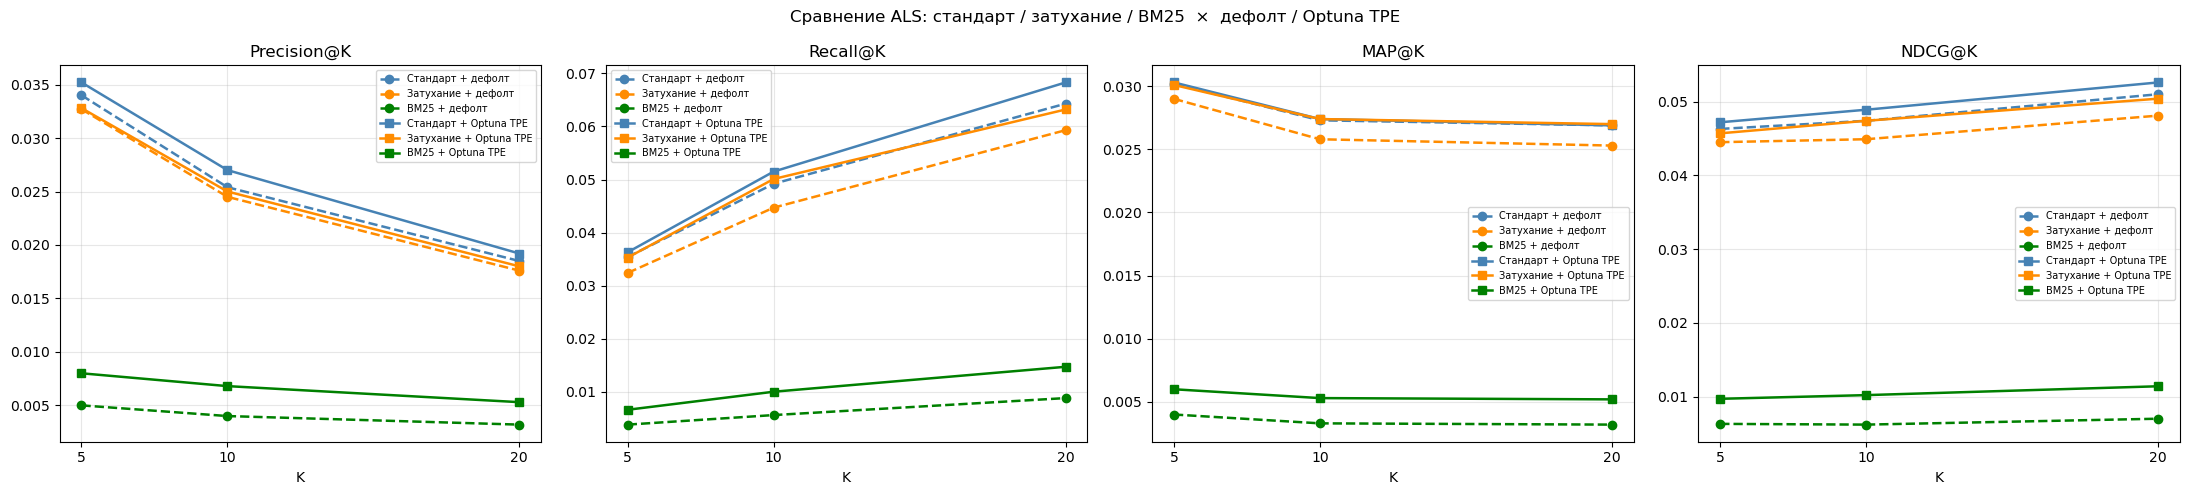

In [141]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['Precision', 'Recall', 'MAP', 'NDCG']
# дефолтные — пунктир, Optuna — сплошная; цвет = тип матрицы
style_map = {
    'Стандарт + дефолт':      ('steelblue',  '--', 'o'),
    'Затухание + дефолт':     ('darkorange', '--', 'o'),
    'BM25 + дефолт':          ('green',      '--', 'o'),
    'Стандарт + Optuna TPE':  ('steelblue',  '-',  's'),
    'Затухание + Optuna TPE': ('darkorange', '-',  's'),
    'BM25 + Optuna TPE':      ('green',      '-',  's'),
}
k_values = [5, 10, 20]

for ax, metric in zip(axes, metrics):
    for label, _ in all_variants:
        color, ls, marker = style_map[label]
        subset = comparison_df[comparison_df['Вариант'] == label]
        ax.plot(subset['K'], subset[metric],
                marker=marker, label=label, color=color,
                linestyle=ls, linewidth=1.8)
    ax.set_title(f'{metric}@K')
    ax.set_xlabel('K')
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Сравнение ALS: стандарт / затухание / BM25  ×  дефолт / Optuna TPE', fontsize=12)
plt.tight_layout()
plt.show()

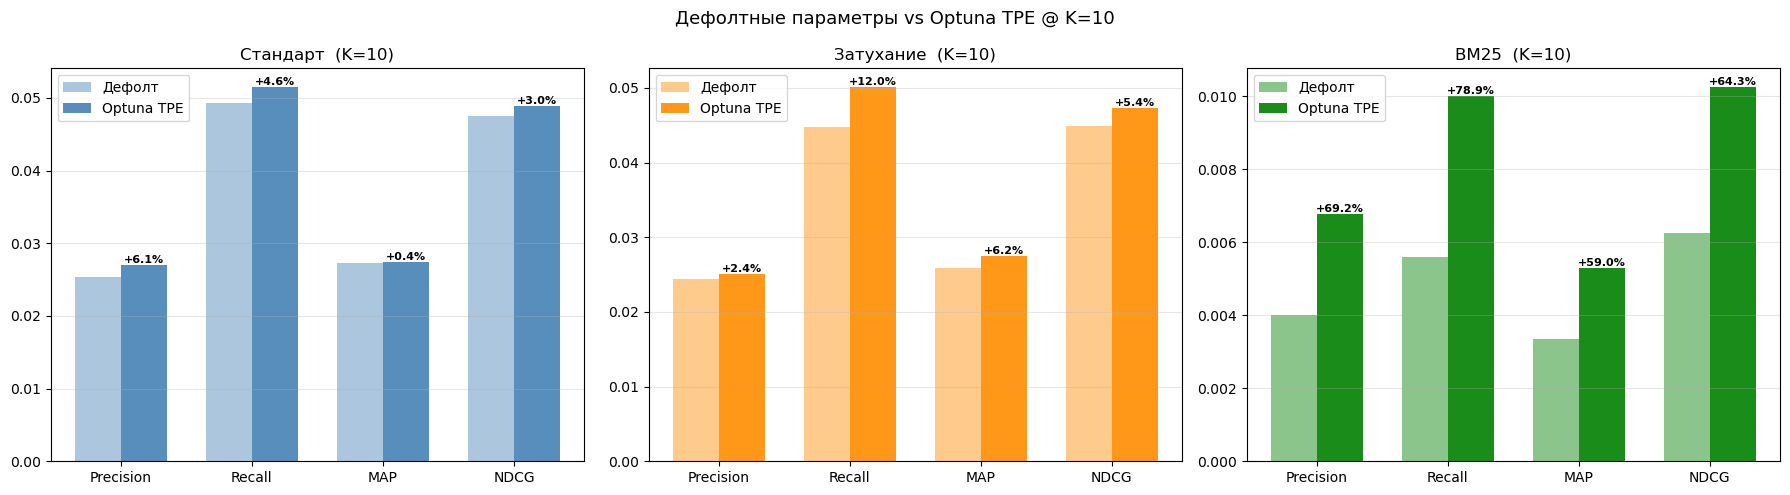

In [142]:
K_PLOT = 10
metric_names = ['Precision', 'Recall', 'MAP', 'NDCG']
metric_keys  = ['precision', 'recall', 'map', 'ndcg']

approaches = [
    ('Стандарт',  results_standard_baseline, results_standard_optuna, 'steelblue'),
    ('Затухание', results_decay_baseline,    results_decay_optuna,    'darkorange'),
    ('BM25',      results_bm25_baseline,     results_bm25_optuna,     'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(metric_names))
width = 0.35

for ax, (name, before, after, color) in zip(axes, approaches):
    vals_before = [before[K_PLOT][m] for m in metric_keys]
    vals_after  = [after[K_PLOT][m]  for m in metric_keys]

    ax.bar(x - width/2, vals_before, width, label='Дефолт',     color=color, alpha=0.45)
    ax.bar(x + width/2, vals_after,  width, label='Optuna TPE', color=color, alpha=0.9)

    for b_val, a_val, xi in zip(vals_before, vals_after, x):
        delta = (a_val - b_val) / b_val * 100 if b_val > 0 else 0
        ax.annotate(f'{delta:+.1f}%',
                    xy=(xi + width/2, a_val),
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(f'{name}  (K={K_PLOT})')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Дефолтные параметры vs Optuna TPE @ K={K_PLOT}', fontsize=13)
plt.tight_layout()
plt.show()

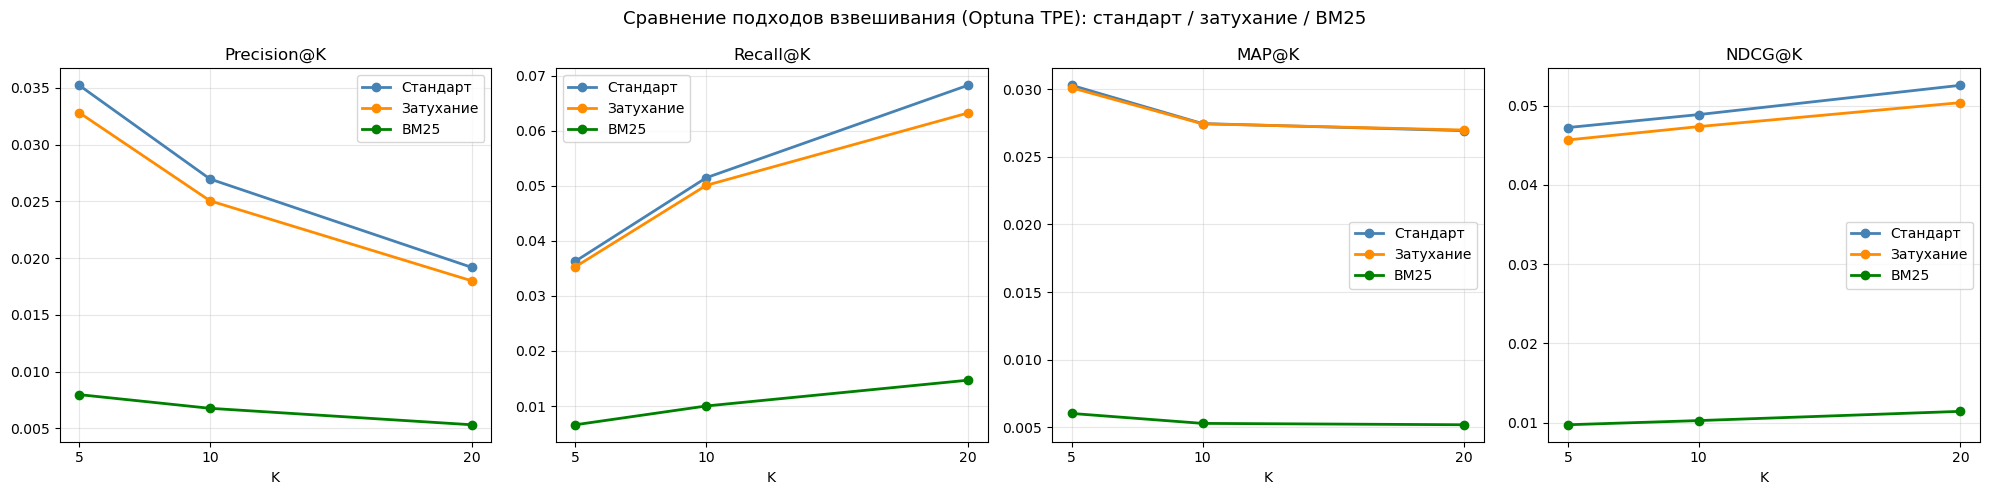

In [143]:
optuna_variants = [
    ('Стандарт',  results_standard_optuna, 'steelblue'),
    ('Затухание', results_decay_optuna,    'darkorange'),
    ('BM25',      results_bm25_optuna,     'green'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
k_values = [5, 10, 20]

for ax, (mname, mkey) in zip(axes, zip(metric_names, metric_keys)):
    for name, results, color in optuna_variants:
        vals = [results[k][mkey] for k in k_values]
        ax.plot(k_values, vals, marker='o', label=name, color=color, linewidth=2)
    ax.set_title(f'{mname}@K')
    ax.set_xlabel('K')
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Сравнение подходов взвешивания (Optuna TPE): стандарт / затухание / BM25', fontsize=13)
plt.tight_layout()
plt.show()

In [144]:
lambdas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]

# предвычисляем один раз
_base = train_data.groupby(['user_id', 'item_id']).agg(
    count=('count', 'sum'), mean_date=('Дата', 'mean')
).reset_index()
_user_ids = _base['user_id'].values
_item_ids = _base['item_id'].values
_counts   = _base['count'].values.astype(float)
_days     = (split_date - _base['mean_date']).dt.total_seconds().values / 86400

lambda_results = []
for lam in lambdas:
    weights = (_counts * np.exp(-lam * _days)).clip(1e-6)
    mat = csr_matrix((weights, (_user_ids, _item_ids)), shape=(n_users, n_items))

    m = AlternatingLeastSquares(
        factors=50, regularization=0.01, iterations=15,
        calculate_training_loss=False, random_state=42
    )
    m.fit(mat, show_progress=False)
    r = evaluate_model(m, mat, test_interactions, k_values=[5, 10, 20])

    row = {'lambda': lam}
    for k in [5, 10, 20]:
        for metric in ['precision', 'recall', 'map', 'ndcg']:
            row[f'{metric}@{k}'] = r[k][metric]
    lambda_results.append(row)
    print(f'lambda={lam:.3f}  MAP@5={r[5]["map"]:.4f}  MAP@10={r[10]["map"]:.4f}  MAP@20={r[20]["map"]:.4f}')

lambda_df = pd.DataFrame(lambda_results)
best_lam = lambdas[lambda_df['map@10'].argmax()]
print(f'\nОптимальный lambda по MAP@10: {best_lam}')
print(lambda_df[['lambda', 'map@5', 'map@10', 'map@20']].to_string(index=False))

lambda=0.001  MAP@5=0.0301  MAP@10=0.0272  MAP@20=0.0268
lambda=0.005  MAP@5=0.0295  MAP@10=0.0264  MAP@20=0.0259
lambda=0.010  MAP@5=0.0290  MAP@10=0.0258  MAP@20=0.0253
lambda=0.020  MAP@5=0.0274  MAP@10=0.0242  MAP@20=0.0236
lambda=0.050  MAP@5=0.0221  MAP@10=0.0188  MAP@20=0.0180
lambda=0.100  MAP@5=0.0201  MAP@10=0.0163  MAP@20=0.0152
lambda=0.200  MAP@5=0.0152  MAP@10=0.0123  MAP@20=0.0116

Оптимальный lambda по MAP@10: 0.001
 lambda    map@5   map@10   map@20
  0.001 0.030068 0.027174 0.026753
  0.005 0.029451 0.026383 0.025911
  0.010 0.029013 0.025829 0.025267
  0.020 0.027403 0.024226 0.023590
  0.050 0.022087 0.018766 0.017981
  0.100 0.020053 0.016299 0.015230
  0.200 0.015192 0.012320 0.011604


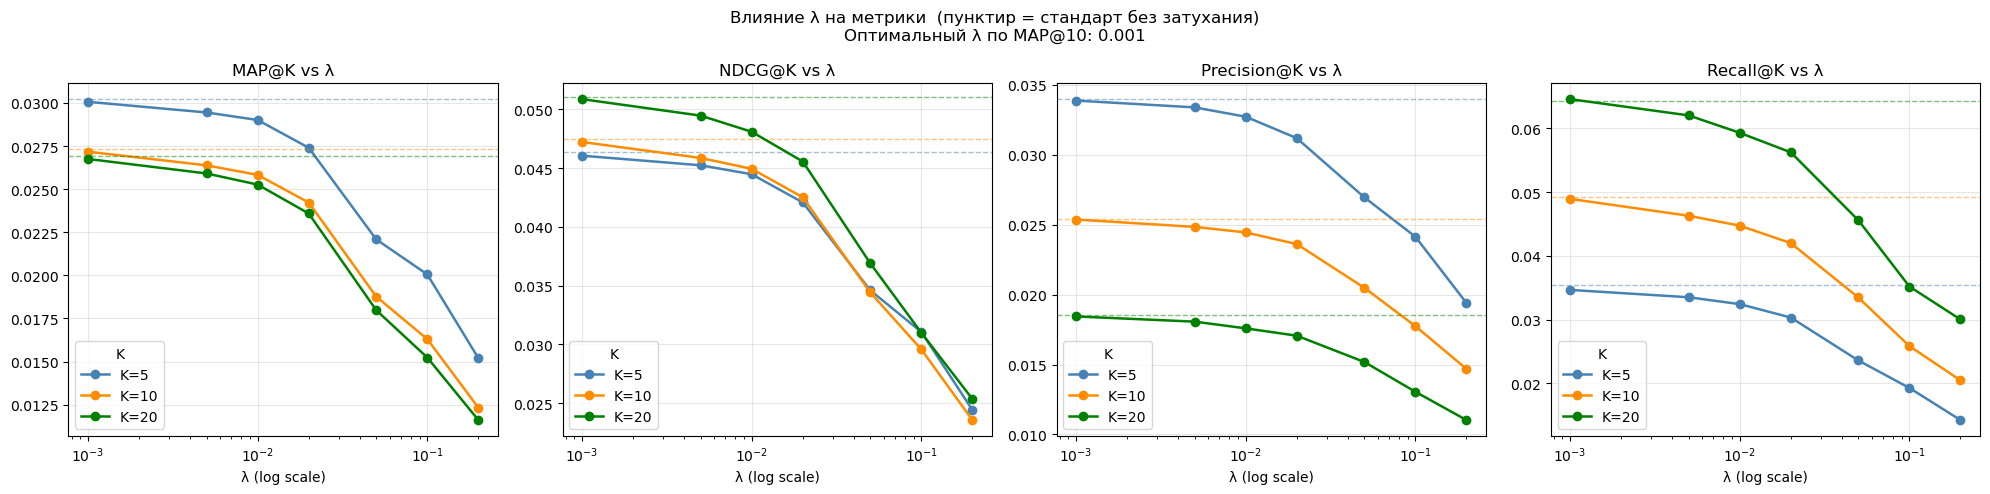

In [145]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_pairs = [('MAP', 'map'), ('NDCG', 'ndcg'), ('Precision', 'precision'), ('Recall', 'recall')]

for ax, (mname, mkey) in zip(axes, plot_pairs):
    for k, color in [(5, 'steelblue'), (10, 'darkorange'), (20, 'green')]:
        ax.plot(lambda_df['lambda'], lambda_df[f'{mkey}@{k}'],
                marker='o', label=f'K={k}', color=color, linewidth=1.8)
        ax.axhline(results_standard_baseline[k][mkey],
                   color=color, linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('λ (log scale)')
    ax.set_title(f'{mname}@K vs λ')
    ax.legend(title='K')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Влияние λ на метрики  (пунктир = стандарт без затухания)\n'
    f'Оптимальный λ по MAP@10: {best_lam}',
    fontsize=12
)
plt.tight_layout()
plt.show()